In [1]:
import pandas as pd

In [2]:
data = {"Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]}

In [3]:
df = pd.DataFrame(data)

In [4]:
import matplotlib.pyplot as plt

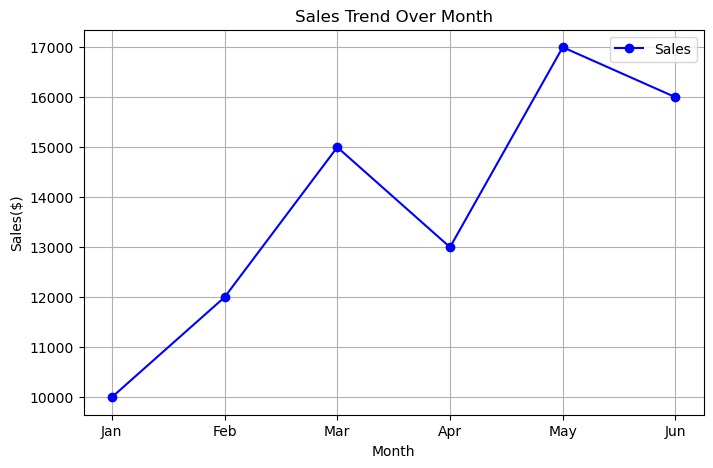

In [13]:
plt.figure(figsize=(8,5))
plt.plot(df['Month'],df['Sales'],color='blue',ls='-',marker='o',label='Sales')
plt.title('Sales Trend Over Month')
plt.xlabel('Month')
plt.ylabel('Sales($)')
plt.legend()
plt.grid()
plt.show()
           

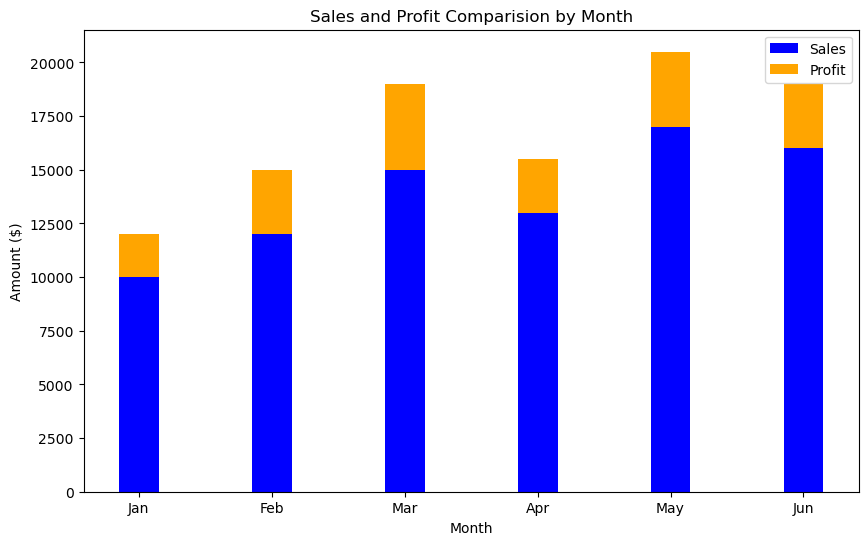

In [27]:
plt.figure(figsize=(10,6))
width = 0.3
plt.bar(df['Month'],df['Sales'],label='Sales',color='blue',width=width)
plt.bar(df['Month'],df['Profit'],label= 'Profit',color='orange',bottom=df['Sales'],width=width)
plt.title('Sales and Profit Comparision by Month')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.show()

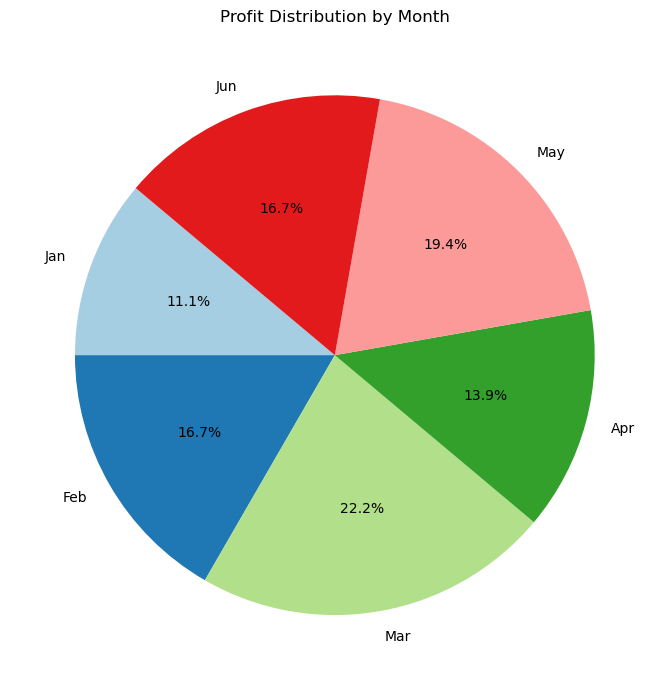

In [56]:
plt.figure(figsize=(7,7))
plt.pie(df['Profit'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Profit Distribution by Month')
plt.tight_layout()
plt.show()


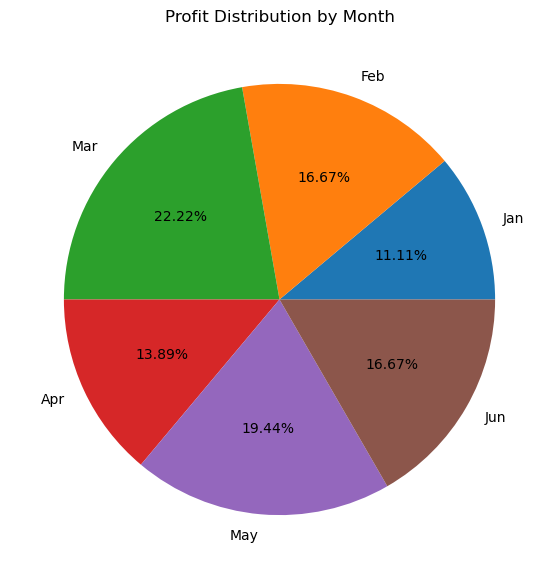

In [60]:
plt.figure(figsize=(7,7))
plt.pie(df['Profit'], labels=df['Month'], autopct='%1.2f%%')
plt.title('Profit Distribution by Month')

plt.show()

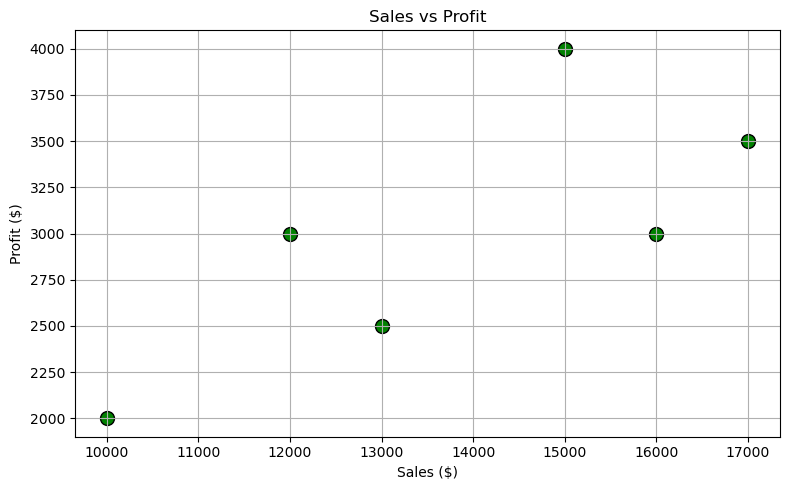

In [61]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
plt.title('Sales vs Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

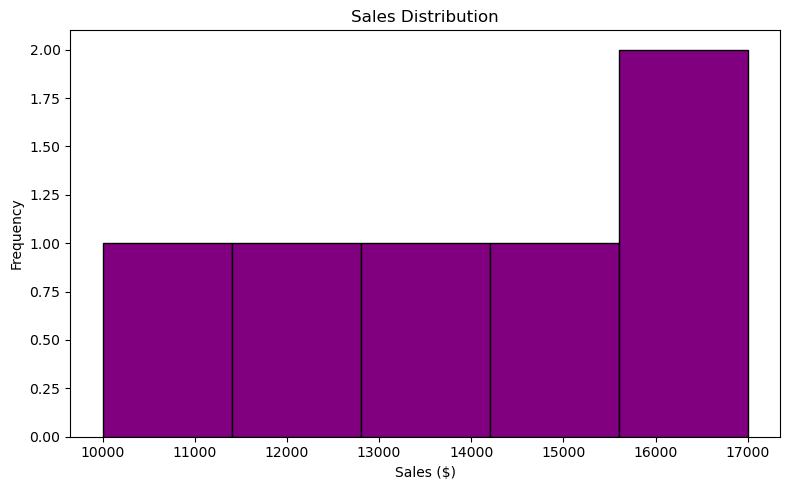

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

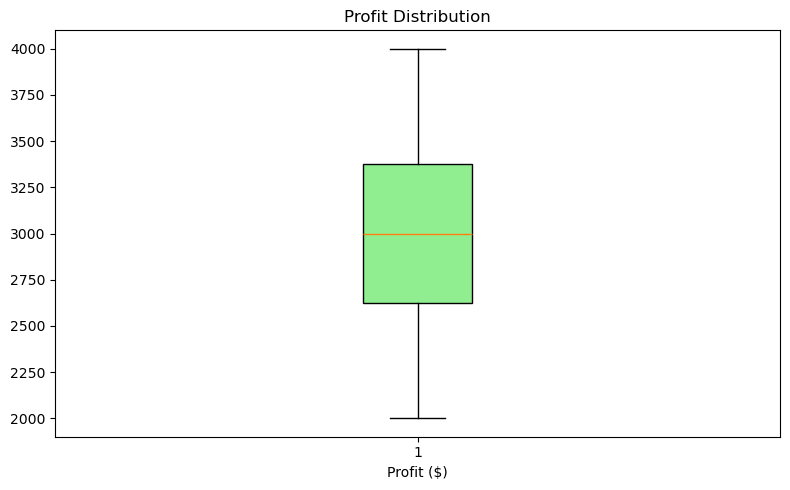

In [70]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Profit'], vert=True, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
plt.title('Profit Distribution')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

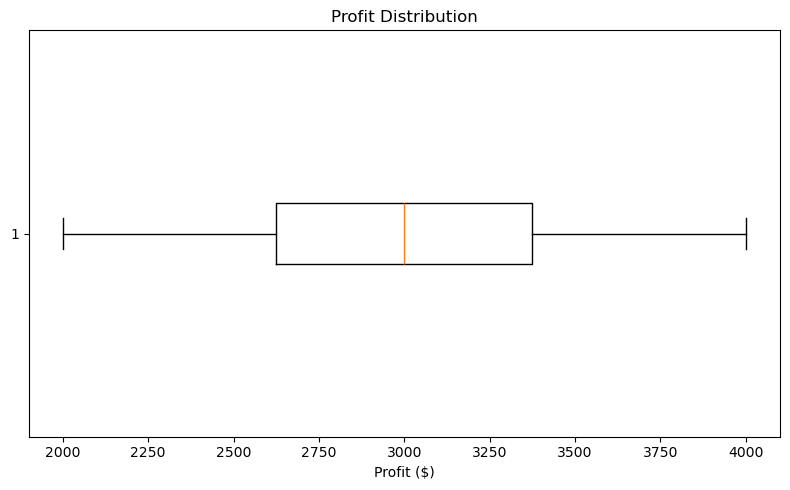

In [72]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Profit'], vert=False)
plt.title('Profit Distribution')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

In [73]:
pip install gradio


   ---------------------------------------- 0.0/59.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/59.6 MB 3.8 MB/s eta 0:00:16
   - -------------------------------------- 2.6/59.6 MB 8.0 MB/s eta 0:00:08
   -- ------------------------------------- 3.7/59.6 MB 6.6 MB/s eta 0:00:09
   --- ------------------------------------ 5.2/59.6 MB 7.0 MB/s eta 0:00:08
   ---- ----------------------------------- 6.6/59.6 MB 6.9 MB/s eta 0:00:08
   ----- ---------------------------------- 8.1/59.6 MB 7.2 MB/s eta 0:00:08
   ------ --------------------------------- 9.7/59.6 MB 6.9 MB/s eta 0:00:08
   ------- -------------------------------- 11.8/59.6 MB 7.4 MB/s eta 0:00:07
   -------- ------------------------------- 13.1/59.6 MB 7.3 MB/s eta 0:00:07
   --------- ------------------------------ 14.2/59.6 MB 7.1 MB/s eta 0:00:07
   ---------- ----------------------------- 16.3/59.6 MB 7.3 MB/s eta 0:00:06
   ------------ --------------------------- 18.1/59.6 MB 7.4 MB/s eta 0:00:06


  You can safely remove it manually.


In [74]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
data = {"Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]}

In [76]:
df = pd.DataFrame(data)

In [77]:
def generate_plot(plot_type):
    fig = plt.figure(figsize=(8, 5))

    if plot_type == "Line Plot":
        plt.plot(df['Month'], df['Sales'], color='blue', marker='o', label='Sales')
        plt.title('Sales Trend Over Months')
        plt.xlabel('Month')
        plt.ylabel('Sales ($)')
        plt.grid(True)
        plt.legend()

    elif plot_type == "Stacked Bar Chart":
        fig.set_size_inches(10, 6)
        width = 0.3
        plt.bar(df['Month'], df['Sales'], width=width, label='Sales', color='skyblue')
        plt.bar(df['Month'], df['Profit'], width=width, label='Profit', color='orange', bottom=df['Sales'])
        plt.title('Sales and Profit Comparison by Month')
        plt.xlabel('Month')
        plt.ylabel('Amount ($)')
        plt.legend()

    elif plot_type == "Pie Chart":
        fig.set_size_inches(7, 7)
        plt.pie(df['Profit'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.title('Profit Distribution by Month')

    elif plot_type == "Scatter Plot":
        plt.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
        plt.title('Sales vs Profit')
        plt.xlabel('Sales ($)')
        plt.ylabel('Profit ($)')
        plt.grid(True)

    elif plot_type == "Histogram":
        plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
        plt.title('Sales Distribution')
        plt.xlabel('Sales ($)')
        plt.ylabel('Frequency')

    elif plot_type == "Box Plot":
        plt.boxplot(df['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
        plt.title('Profit Distribution')
        plt.xlabel('Profit ($)')

    plt.tight_layout()
    return fig

# Gradio UI
demo = gr.Interface(
    fn=generate_plot,
    inputs=gr.Radio(
        ["Line Plot", "Stacked Bar Chart", "Pie Chart", "Scatter Plot", "Histogram", "Box Plot"],
        label="Choose Plot Type"
    ),
    outputs=gr.Plot(label="Visualization"),
    title="Sales & Profit Visual Explorer",
    description="Choose a chart type to visualize the data."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
